STEP 1 — Import Libraries

In [3]:
# Import pandas for working with tables (DataFrames)
import pandas as pd

# Import numpy for mathematical operations
import numpy as np

# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Import Logistic Regression algorithm
from sklearn.linear_model import LogisticRegression

# Import train_test_split to divide data into training and testing sets
from sklearn.model_selection import train_test_split

# Import LabelEncoder to convert text into numbers
from sklearn.preprocessing import LabelEncoder

# Import evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

STEP 2 — Load Dataset

In [4]:
# Read the CSV file into a pandas DataFrame
df = pd.read_csv("/content/Customer-Churn.csv")

# Display the first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


STEP 3 — Explore the Dataset

In [5]:
# Check number of rows and columns
df.shape

# View column names
df.columns

# View data types
df.dtypes

# Display summary statistics
df.describe()

# Check missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


STEP 4 — Select Important Columns

Suppose we'll use

Tenure

MonthlyCharges

TotalCharges

Target

Churn

In [6]:
# Select useful features
df = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

STEP 5 — Convert TotalCharges into Numbers

Sometimes TotalCharges is stored as text.

In [7]:
# Convert TotalCharges into numeric values
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

STEP 6 — Remove Missing Values

In [8]:
# Remove rows containing missing values
df = df.dropna()

STEP 7 — Encode the Target Variable

Current values

Yes
No

Need

1
0

In [9]:
# Create LabelEncoder object
encoder = LabelEncoder()

# Convert Yes and No into 1 and 0
df["Churn"] = encoder.fit_transform(df["Churn"])

STEP 8 — Define Features and Target

In [10]:
# Features (inputs)
X = df[["tenure", "MonthlyCharges", "TotalCharges"]]

# Target (output)
y = df["Churn"]

STEP 9 — Split the Dataset

In [11]:
# Split into training and testing datasets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

STEP 10 — Create the Logistic Regression Model

In [12]:
# Create Logistic Regression model
model = LogisticRegression()

STEP 11 — Train the Model

In [13]:
# Teach the model using training data
model.fit(X_train, y_train)

LogisticRegression()

STEP 12 — Make Predictions

In [14]:
# Predict customer churn
predictions = model.predict(X_test)

STEP 13 — View Predictions

In [15]:
# Show first ten predictions
predictions[:10]

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0])

STEP 14 — Prediction Probabilities

In [16]:
# Predict probabilities instead of just classes
probabilities = model.predict_proba(X_test)

# Display first five probabilities
probabilities[:5]

array([[0.99219584, 0.00780416],
       [0.8910046 , 0.1089954 ],
       [0.30296097, 0.69703903],
       [0.89713252, 0.10286748],
       [0.75049037, 0.24950963]])

STEP 15 — Accuracy

In [17]:
# Calculate model accuracy
accuracy = accuracy_score(y_test, predictions)

# Print the accuracy
print("Accuracy:", accuracy)

Accuracy: 0.7796730632551528


STEP 16 — Confusion Matrix

In [18]:
# Generate confusion matrix
cm = confusion_matrix(y_test, predictions)

# Display confusion matrix
print(cm)

[[937  96]
 [214 160]]


STEP 17 — Classification Report

In [19]:
# Display precision, recall and F1-score
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.81      0.91      0.86      1033
           1       0.62      0.43      0.51       374

    accuracy                           0.78      1407
   macro avg       0.72      0.67      0.68      1407
weighted avg       0.76      0.78      0.76      1407



STEP 18 — Predict a New Customer

Suppose

Tenure

10 months

Monthly Charges

70

Total Charges

700

In [20]:
# Create a new customer
new_customer = [[10, 70, 700]]

# Predict churn
prediction = model.predict(new_customer)

# Predict probability
probability = model.predict_proba(new_customer)

print("Prediction:", prediction)

print("Probability:", probability)

Prediction: [0]
Probability: [[0.51312927 0.48687073]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


STEP 19 — Understanding the Coefficients (Model Explainability)

One advantage of Logistic Regression is that it is an interpretable model. We can inspect the learned coefficients to understand how each feature influences the prediction.

In [21]:
# Create a table showing each feature and its learned coefficient
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

# Display the coefficients
print(coefficients)

          Feature  Coefficient
0          tenure    -0.069735
1  MonthlyCharges     0.030491
2    TotalCharges     0.000169


How to interpret the coefficients

A positive coefficient means that as the feature increases, the likelihood of churn increases (assuming other features stay the same).

A negative coefficient means that as the feature increases, the likelihood of churn decreases.

A larger absolute value indicates a stronger influence on the prediction.

For example, if MonthlyCharges has a positive coefficient, customers with higher monthly charges may be more likely to leave.

STEP 20 — Visualize the Feature Importance

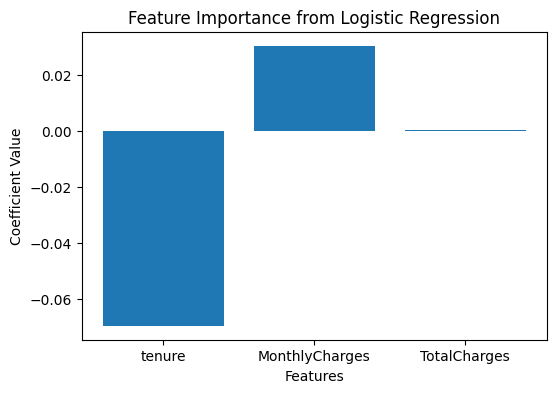

In [22]:
# Create a bar chart of the logistic regression coefficients
plt.figure(figsize=(6,4))

# Plot the coefficients
plt.bar(coefficients["Feature"], coefficients["Coefficient"])

# Add a title
plt.title("Feature Importance from Logistic Regression")

# Label the x-axis
plt.xlabel("Features")

# Label the y-axis
plt.ylabel("Coefficient Value")

# Display the chart
plt.show()

Interpretation of the Chart

Feature	Coefficient	Interpretation

Tenure	-0.07	Customers who have stayed longer are less likely to churn. This is the strongest predictor in your model because it has the largest coefficient in magnitude.

MonthlyCharges	+0.03	Customers with higher monthly charges are more likely to churn. As monthly charges increase, the probability of leaving also increases.

TotalCharges	≈ 0	This feature has almost no influence on the prediction in this model. It contributes very little compared to the other features.

What do Positive and Negative Coefficients Mean?

Positive coefficient (+) → As the feature increases, the probability of the customer churning (leaving) increases.

Negative coefficient (-) → As the feature increases, the probability of the customer staying increases (or equivalently, the probability of churn decreases).

In the chart:

Tenure is negative, meaning customers who have been with the company for a longer time are more loyal and less likely to leave.

MonthlyCharges is positive, meaning customers paying higher monthly fees tend to leave more often.

TotalCharges is very close to zero, suggesting it doesn't add much predictive information after considering the other two features.

Which Feature is Most Important?

Looking at the absolute values of the coefficients:

Tenure: 0.07

MonthlyCharges: 0.03

TotalCharges: 0.00

Tenure is the most influential feature because it has the largest absolute coefficient. This suggests that customer loyalty (measured by how long they've stayed) is the strongest factor affecting churn in your model.

Why is TotalCharges Nearly Zero?

There are two likely reasons:

Correlation with Tenure: Total charges are largely determined by how long a customer has been with the company, so the model may already capture this information through the tenure feature.

Small Additional Contribution: Once tenure and MonthlyCharges are included, TotalCharges provides little extra information for predicting churn.